In [1]:
import os, sys
import random
import fitsio
import numpy as np
from astropy.table import Table,join,unique,vstack
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import ticker
import random

sys.path.append('../../')
from helper import REDSHIFT_BIN_LSS
%load_ext autoreload
%autoreload 2

sys.path.append('/global/homes/s/shengyu/packages/LSS/py/LSS')
from globals import main
import common_tools as common

outdir = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'

def get_repeats(indat, labels = None):
    if labels is None:
        labels = ['Z']
    tids,cnts = np.unique(indat['TARGETID'],return_counts=True)
    rtids = tids[cnts>1]
    sel_r = np.isin(indat['TARGETID'],rtids)
    specflr = indat[sel_r]
    print("N rows with TARGETID repeated:", len(specflr))
    specflr.sort("TARGETID")
    out = {'TARGETID': []}
    for lab in labels:
        out[f'{lab}_1'] = []
        out[f'{lab}_2'] = []
    ind = 0
    n = len(specflr)
    while ind < n:
        row1 = specflr[ind]
        tid = row1['TARGETID']
        ind2 = 1
        while ind + ind2 < n and specflr[ind + ind2]['TARGETID'] == tid:
            row2 = specflr[ind + ind2]
            out['TARGETID'].append(tid)
            for lab in labels:
                out[f'{lab}_1'].append(row1[lab])
                out[f'{lab}_2'].append(row2[lab])
            ind2 += 1
        ind += ind2
        if ind % 100000 == 0:
            print("processed", ind)
    return Table(out)

## For dark tracers

In [15]:
survey = 'DA2'
time = 'dark'

mainp = main('LRG', 'loa-v1')#get settings for dark time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/global/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf = Table(fitsio.read(specfo.replace('global','dvs_ro')))
sel = np.isin(specf['TILEID'],mtld['TILEID'])
specf = specf[sel]
specf = Table(specf)
specf.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','DESI_TARGET','TILEID','TSNR2_LRG','TSNR2_ELG', 'TSNR2_QSO', 'ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT', 'Z_QN','Z_QN_CONF','IS_QSO_QN' ])
specf = common.cut_specdat(specf,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

LRG
number with no data 114111
number with bad qa 730556
number at low tsnr2 487520
will mask fibers with time dependence
number removed from time dependent mask is 411848
number removed from spike mask is 56226
number removed from petal night mask is 133031


In [16]:
specf

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,DESI_TARGET,TILEID,TSNR2_ELG,TSNR2_LRG,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,int64,int32,int32,int64,int32,float32,float32,float32,int64,float64,float64,int16
2204596575404032,20211207,0.9202842403601226,8.215467697228755e-05,4,6.247507736086845,7231,3696,0,4611686018427387904,5843,149.73386,100.694695,33.79132,4,2.1043300258932427,0.0011781915615822337,0
2204623473475584,20240109,0.18525533312667702,6.52643938379786e-05,4,0.6904128678143024,187,29,0,4611686018427387904,6271,110.81747,75.89079,27.704742,4,0.9887578312190795,7.508927148918077e-05,0
2204652607111168,20220309,0.016411489188294572,3.191587475369417e-05,0,24.80390017834725,7423,3771,0,4611686018427387904,10367,147.25053,93.63391,30.293745,0,1.7035186598092165,0.010176743245881605,0
2204698811564032,20221027,1.4071094922636993,0.00012600868959775256,4,0.7681537866592407,5227,2599,0,4611686018427387904,9492,128.25554,87.42097,30.562073,4,1.590997353036471,0.002710550342419712,0
2204712820539392,20220301,0.016040149651302335,2.3910465384871773e-05,0,22.177696721395478,3425,1767,0,4611686018427387904,2558,113.28457,78.879616,23.58123,0,1.6467931095079722,0.048941458323948105,0
2204728519819264,20211008,0.4540019230769707,6.778581023548571e-05,4,4.886444889008999,7087,3979,0,4611686018427387904,1154,113.35596,77.30165,31.76311,4,1.8195670332322287,0.0006004674747686866,0
2204728519819264,20230811,0.957850132167,9.628853805861223e-05,4,0.028908050036989152,234,32,0,4611686018427387904,10945,106.028465,77.431335,29.988216,4,2.1602167872918034,0.010017138502105413,0
2204739815079936,20220924,1.1776288678684068,0.0001110576993158109,4,1.889523059129715,2265,1338,0,4611686018427387904,11237,125.48263,84.69672,33.359737,4,1.932610405961769,0.4180600009749265,0
2204743308935168,20220306,0.03313254973460166,4.098895526668919e-05,0,10.253139491425827,9209,4911,0,4611686018427387904,2848,124.665565,81.85579,28.181976,0,1.7067155034256958,0.0039002353330136025,0


In [17]:
tracer = 'LRG'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

sel_LRG = (specf['DESI_TARGET']) & 1 > 0
sel_gz = common.goodz_infull('LRG',specf,zcol='Z')
specfl = specf[sel_LRG&sel_gz]

lrgr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# lrgr = get_repeats(specfl,labels=labels)
# lrgr.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

In [18]:
tracer = 'ELG'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

elgf = fitsio.read(mainp.elgzf,columns=['TARGETID','LOCATION','TILEID','OII_FLUX','OII_FLUX_IVAR'])
specfe_ = join(specf,elgf,keys=['TARGETID','TILEID','LOCATION'],join_type='left')
o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
w = (o2c*0) != 0
w |= specfe_['OII_FLUX'] < 0
o2c[w] = -20
specfe_['o2c'] = o2c
sel_ELG = (specfe_['DESI_TARGET'] & 2) > 0
sel_gz = common.goodz_infull('ELG',specfe_,zcol='Z')
specfe = specfe_[sel_ELG&sel_gz]

elgr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# elgr = get_repeats(specfe, labels=labels)
# elgr.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

/tmp/ipykernel_363387/3547978879.py:7: RuntimeWarning: divide by zero encountered in log10
  o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
/tmp/ipykernel_363387/3547978879.py:7: RuntimeWarning: invalid value encountered in log10
  o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
/tmp/ipykernel_363387/3547978879.py:8: RuntimeWarning: invalid value encountered in multiply
  w = (o2c*0) != 0


In [19]:
tracer = 'QSO'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

qsof = fitsio.read(mainp.qsozf,columns=['TARGETID','LOCATION','TILEID','Z'])
specfq_ = join(specf,qsof,keys=['TARGETID','TILEID','LOCATION'],join_type='left',uniq_col_name='{col_name}{table_name}',table_names=['','_QF'])
selqso = specfq_['Z_QF']!=999999
selqso &= (specfq_['DESI_TARGET'] & 4) > 0
specfq = specfq_[selqso]

qsor = Table.read(outdir+f'/{tracer}repeats_info.fits')
# qsor = get_repeats(specfq, labels=labels)
# qsor.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

## For bright tracers

In [26]:
survey = 'DA2'
time = 'bright'

mainp = main('BGS', 'loa-v1')#get settings for bright time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/global/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo_ = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf_ = Table(fitsio.read(specfo_.replace('global','dvs_ro')))
sel = np.isin(specf_['TILEID'],mtld['TILEID'])
specf_ = specf_[sel]
specf_ = Table(specf_)
specf_.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','BGS_TARGET','TILEID','TSNR2_BGS','TSNR2_ELG','ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT'])
specf_ = common.cut_specdat(specf_,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

BGS
number with no data 86136
number with bad qa 508781
number at low tsnr2 453265
will mask fibers with time dependence
number removed from time dependent mask is 317259
number removed from spike mask is 42775
number removed from petal night mask is 23826


In [27]:
tracer = 'BGS'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

sel_BGS = specf_['BGS_TARGET'] > 0
sel_gz = common.goodz_infull('BGS',specf_,zcol='Z')
specfb = specf_[sel_BGS&sel_gz]

bgsr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# bgsr = get_repeats(specfb, labels=labels)
# bgsr.write(outdir+'/BGSrepeats_info.fits',overwrite=True)

# PLOT

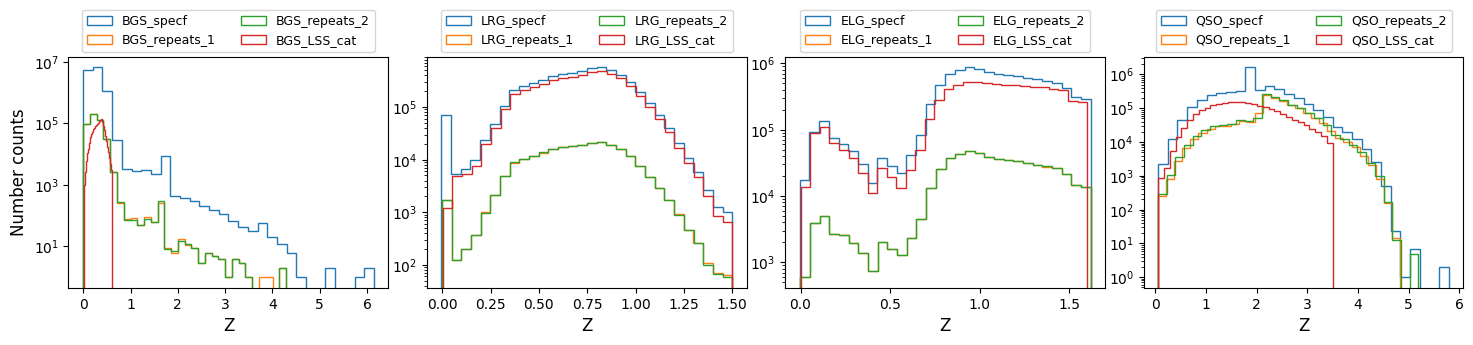

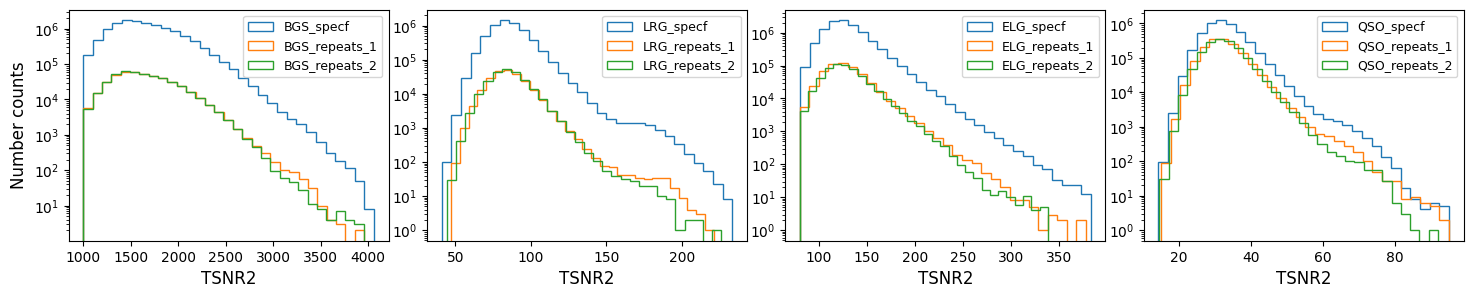

In [ ]:
tracers = ['BGS', 'LRG','ELG','QSO']
specf_all = [specfb, specfl, specfe, specfq]
tr_all = [bgsr, lrgr, elgr, qsor]

fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.12,hspace=0.1)
for idx, tracer, specfsab, tr in zip(range(len(tracers)), tracers, specf_all, tr_all):
    ax = plt.subplot(gs[idx])
    zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
    ax.hist(specfsab[zcol], bins=30, histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'{zcol}_1'], bins=30, histtype='step', label=f'{tracer}_repeats_1')
    ax.hist(tr[f'{zcol}_2'], bins=30, histtype='step', label=f'{tracer}_repeats_2')
    path = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP'
    if tracer =='BGS': 
        tracer_label = 'BGS_BRIGHT-21.35'
    elif tracer == 'ELG':
        tracer_label = 'ELG_LOPnotqso'
    else:
        tracer_label = tracer
    data = Table.read(path+f'/{tracer_label}_clustering.dat.fits')
    ax.hist(data['Z'], bins=30, histtype='step', label = f'{tracer}_LSS_cat')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.23), fontsize=9, ncol=2)
    # ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('Z', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')

fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.12,hspace=0.1)
for idx, tracer, specfsab, tr in zip(range(len(tracers)), tracers, specf_all, tr_all):
    ax = plt.subplot(gs[idx])
    ax.hist(specfsab[f'TSNR2_{tracer}'], bins=30, histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'TSNR2_{tracer}_1'], bins=30, histtype='step', label=f'{tracer}_repeats_1')
    ax.hist(tr[f'TSNR2_{tracer}_2'], bins=30, histtype='step', label=f'{tracer}_repeats_2')
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=11, ncol=3)
    ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('TSNR2', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')

In [75]:
path = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP'
data = Table.read(path+f'/{tracer}_clustering.dat.fits')
data

TARGETID,TILEID,NTILE,RA,DEC,PHOTSYS,Z,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_IMLIN,WEIGHT_SYS,WEIGHT,WEIGHT_COMP
int64,int64,int64,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,float64
39627322701125813,1169,1,21.876410751633088,-19.44134382450835,S,2.4147343976888758,0.9862681744749596,1.1243407726287842,0.9795196056365967,0.9795196056365967,2.202627660412986,2.0
39627322701128888,1169,1,21.970054362083097,-19.41049376322168,S,3.0154471067835114,0.9862681744749596,1.0687103271484375,0.9795196056365967,0.9795196056365967,1.0468227181881957,1.0
39627322705320844,1169,1,22.165120364661878,-19.38537156552792,S,1.5724607556496883,0.9862681744749596,1.076799988746643,0.9924231767654419,0.9924231767654419,1.0686412655729356,1.0
39627322705321907,1169,1,22.19615939639026,-19.388861440289986,S,1.5291193759823845,0.9862681744749596,1.1011314392089844,0.9924231767654419,0.9924231767654419,1.0927883609360833,1.0
39627322709514577,1169,1,22.409658386562008,-19.388786997297064,S,1.7646240493186662,0.9862681744749596,1.1451902389526367,0.9896571040153503,0.9896571040153503,1.1333456554285135,1.0
39627323120558797,2446,1,48.434226224228084,-19.430134035993415,S,1.5424038141175873,0.9716981132075472,1.0,1.020554542541504,1.020554542541504,1.020554542541504,1.0
39627323124748972,2446,1,48.59381358198363,-19.38441935595103,S,2.451788726239304,0.9716981132075472,1.0125689506530762,0.9781806468963623,0.9781806468963623,0.9904753511769968,1.0
39627323342851641,7146,1,62.295351753885896,-19.37790424426939,S,1.4669453904413403,0.9808917197452229,1.0,0.9596964716911316,0.9596964716911316,0.9596964716911316,1.0
39627328392794748,1169,1,21.025564410792047,-19.157535498555323,S,1.3103705929578875,0.9862681744749596,1.0878766775131226,0.9915021657943726,0.9915021657943726,1.0786320818714472,1.0
